<hr>
<h1>Task 1: Data Cleaning and Formatting</h1>

<p>
The objective of Task 1 was to prepare the raw transactional dataset for analysis by ensuring data
accuracy, consistency, and usability. Since all subsequent analysis depends on clean data, this
step focused on validating numerical fields, date formats, and categorical variables.
</p>

<h4>Data Cleaning Steps Performed</h4>
<ul>
  <li><b>Financial Fields Cleaning:</b> TransactionAmount, AccountBalance, and RiskScore were validated
  and converted into proper numeric formats by removing any potential non-numeric characters.</li>

  <li><b>Date Validation and Formatting:</b> The TransactionDate column contained mixed date formats.
  These were standardized and converted into a datetime format to enable time-based analysis.</li>

  <li><b>Category Standardization:</b> AccountType and TransactionType fields were standardized to
  remove inconsistencies caused by casing or extra spaces.</li>
</ul>

<h4>Data Quality Validation</h4>
<ul>
  <li>No missing values were introduced during the cleaning process.</li>
  <li>All financial fields were successfully converted to numeric data types.</li>
  <li>The TransactionDate column was converted from text to a datetime format.</li>
  <li>Categorical fields were made consistent for reliable grouping and aggregation.</li>
</ul>

<h4>Business Impact</h4>
<p>
This data cleaning process ensures that all subsequent analyses—such as transaction trend analysis,
customer profiling, risk identification, and hypothesis testing—are based on reliable and
consistent data. By validating data types and formats at the beginning, the risk of incorrect
insights or misleading conclusions is significantly reduced.
</p>

<p>
Overall, Task 1 establishes a strong foundation for accurate financial analysis and
data-driven decision-making in the later stages of the project.
</p>

<hr>

In [1]:
# checking the dataset
import pandas as pd
df = pd.read_csv('jp_morgan.csv')
print(df.shape)
print(df.head())
print(df.info())

(800, 15)
   TransactionID CustomerID AccountID AccountType TransactionType  \
0              3   CUST2412  ACC80131        Loan      Withdrawal   
1             32   CUST1467  ACC74631     Current      Withdrawal   
2              9   CUST2699  ACC39482        Loan      Withdrawal   
3             42   CUST9535  ACC82947     Current      Withdrawal   
4            166   CUST7459  ACC39500      Credit         Payment   

         Product    Firm Region    Manager TransactionDate  TransactionAmount  \
0  Personal Loan  Firm C   West  Manager 3        6/8/2023        33759.69057   
1      Home Loan  Firm D  North  Manager 2       8/11/2023        69319.19933   
2    Credit Card  Firm D   West  Manager 4      15-05-2024        42831.48483   
3      Home Loan  Firm A  South  Manager 4      30-04-2023        70903.79697   
4      Home Loan  Firm D  South  Manager 4      16-02-2023        21948.97355   

   AccountBalance  RiskScore  CreditRating  TenureMonths  
0    126486.40830   0.225824 

In [2]:
# checking null values and summary statistics
print(df.isna().sum())
df.describe()

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64


,TransactionID,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,101.96125,51086.624542,74528.005025,0.473350,576.303750,123.566250
std,58.27147,29076.621451,32608.264579,0.245104,160.816133,66.426755
min,1.00000,-60979.073480,-13812.693060,-0.368537,304.000000,6.000000
25%,49.00000,32589.042120,53547.221090,0.305702,433.000000,67.000000
50%,104.00000,50307.224210,73736.442995,0.461838,573.000000,123.000000
75%,155.25000,70179.479290,95584.413473,0.634402,722.000000,181.000000
max,199.00000,147447.295100,183836.933800,1.345638,849.000000,239.000000


In [3]:
# remove special characters & convert to numeric

financial_cols = ["TransactionAmount", "AccountBalance", "RiskScore"]

for col in financial_cols:
    df[col] = (
        df[col]
        .astype(str)                 # convert to string
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace("₹", "", regex=False)
        .str.strip()
    )
    
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [4]:
# validate and format dates

df["TransactionDate"] = (
    df["TransactionDate"]
    .astype(str)
    .str.replace("-", "/", regex=False)
)

df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"],
    dayfirst=True,
    format="mixed",
    errors="coerce"
)

In [5]:
# categories standardization

category_cols = ["AccountType", "TransactionType"]

for col in category_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

In [6]:
print(df.dtypes)
df.head()

TransactionID                 int64
CustomerID                      str
AccountID                       str
AccountType                     str
TransactionType                 str
Product                         str
Firm                            str
Region                          str
Manager                         str
TransactionDate      datetime64[us]
TransactionAmount           float64
AccountBalance              float64
RiskScore                   float64
CreditRating                  int64
TenureMonths                  int64
dtype: object


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,3,CUST2412,ACC80131,Loan,Withdrawal,Personal Loan,Firm C,West,Manager 3,2023-08-06,33759.69057,126486.40830,0.225824,611,89
1,32,CUST1467,ACC74631,Current,Withdrawal,Home Loan,Firm D,North,Manager 2,2023-11-08,69319.19933,24834.76291,0.335717,817,174
2,9,CUST2699,ACC39482,Loan,Withdrawal,Credit Card,Firm D,West,Manager 4,2024-05-15,42831.48483,123007.43530,0.572453,332,31
3,42,CUST9535,ACC82947,Current,Withdrawal,Home Loan,Firm A,South,Manager 4,2023-04-30,70903.79697,73073.64225,0.571993,626,92
4,166,CUST7459,ACC39500,Credit,Payment,Home Loan,Firm D,South,Manager 4,2023-02-16,21948.97355,113405.32820,0.380675,411,13


In [7]:
# exporting the cleaned dataset to a new CSV file
df.to_csv("jp_morgan_cleaned.csv", index=False)

<hr>
<h1>Task 2: Descriptive Transactional Analysis</h1>

<p>
In this task, transactional data was analyzed to understand money inflow and outflow patterns across
time and customer accounts. The objective was to identify transaction trends, account performance,
and inactivity risk.
</p>

<h4>Assumptions</h4>
<ul>
  <li>Deposit → Credit (Money In)</li>
  <li>Withdrawal, Payment, Transfer → Debit (Money Out)</li>
  <li>Accounts are considered dormant if the gap between transactions is ≥ 60 days</li>
</ul>

<h4>Analysis Performed</h4>
<ul>
  <li>Calculated monthly and yearly totals of credits, debits, and net transaction volume</li>
  <li>Visualized credit vs debit trends over time</li>
  <li>Identified top and bottom performing accounts based on net inflow</li>
  <li>Flagged dormant accounts using transaction date gaps</li>
</ul>

<h4>Key Insights</h4>
<ul>
  <li>Debit transactions consistently exceeded credit transactions, leading to net outflow</li>
  <li>Some months showed sharp debit spikes, indicating higher spending behavior</li>
  <li>A small group of accounts contributed strong positive net inflow</li>
  <li>Several accounts showed prolonged inactivity, indicating potential churn risk</li>
</ul>

<p>
Task 2 successfully transformed raw transaction data into meaningful insights related to transaction
trends, account performance, and inactivity patterns. These findings provide a strong foundation
for customer profiling and financial risk identification in subsequent tasks.
</p>
<hr>

In [8]:
# Create Credit / Debit direction

df["Direction"] = df["TransactionType"].apply(
    lambda x: "Credit" if x == "Deposit" else "Debit"
)

In [9]:
# Create signed transaction amount

df["SignedAmount"] = df.apply(
    lambda row: row["TransactionAmount"]
    if row["Direction"] == "Credit"
    else -row["TransactionAmount"],
    axis=1
)

In [10]:
# Monthly summary: Credit, Debit & Net

df["Month"] = df["TransactionDate"].dt.to_period("M")

monthly_summary = df.groupby("Month").agg(
    TotalCredit=("SignedAmount", lambda x: x[x > 0].sum()),
    TotalDebit=("SignedAmount", lambda x: abs(x[x < 0].sum())),
    NetTransaction=("SignedAmount", "sum")
).reset_index()

monthly_summary.head()

,Month,TotalCredit,TotalDebit,NetTransaction
0,2023-01,590235.376852,2.223481e+06,-1.633246e+06
1,2023-02,788996.819964,1.978630e+06,-1.189633e+06
2,2023-03,595109.789385,1.933693e+06,-1.338583e+06
3,2023-04,616873.592299,2.138430e+06,-1.521556e+06
4,2023-05,745923.736073,1.884342e+06,-1.138418e+06


In [11]:
# Yearly summary

df["Year"] = df["TransactionDate"].dt.year

yearly_summary = df.groupby("Year").agg(
    TotalCredit=("SignedAmount", lambda x: x[x > 0].sum()),
    TotalDebit=("SignedAmount", lambda x: abs(x[x < 0].sum())),
    NetTransaction=("SignedAmount", "sum")
).reset_index()

yearly_summary

,Year,TotalCredit,TotalDebit,NetTransaction
0,2023,8.458304e+06,2.161944e+07,-1.316114e+07
1,2024,2.426239e+06,9.204933e+06,-6.778694e+06


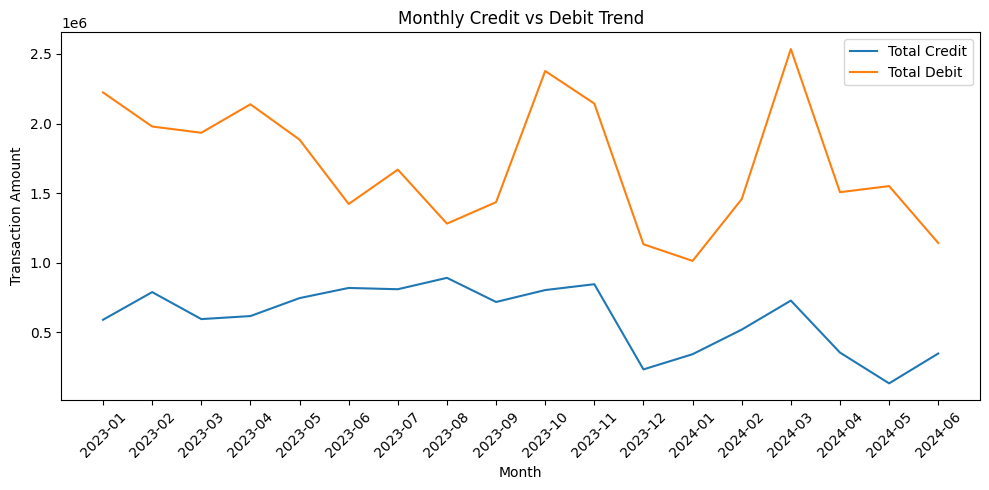

In [12]:
# Plot Credit vs Debit trend over time

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_summary["Month"].astype(str),
         monthly_summary["TotalCredit"],
         label="Total Credit")

plt.plot(monthly_summary["Month"].astype(str),
         monthly_summary["TotalDebit"],
         label="Total Debit")

plt.xticks(rotation=45)
plt.title("Monthly Credit vs Debit Trend")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Identify top & bottom performing accounts

account_performance = df.groupby("AccountID")["SignedAmount"].sum().reset_index()
account_performance.rename(columns={"SignedAmount": "NetInflow"}, inplace=True)

top_accounts = account_performance.sort_values("NetInflow", ascending=False).head(10)
bottom_accounts = account_performance.sort_values("NetInflow").head(10)

print("Top Account\n",top_accounts,"\n")
print("Bottom Account\n",bottom_accounts)

Top Account
     AccountID      NetInflow
109  ACC54589  225122.495180
131  ACC67713  189071.785288
141  ACC74631  150954.104630
169  ACC87602  150860.567520
26   ACC22036  145164.795582
1    ACC10996  124107.378684
115  ACC57872  118892.676040
72   ACC39500  118064.429594
42   ACC28292   93721.351460
100  ACC50817   83157.353560 

Bottom Account
     AccountID      NetInflow
17   ACC18140 -458219.210460
110  ACC55331 -448188.410346
103  ACC51593 -414370.119240
4    ACC11285 -373189.528410
158  ACC81631 -342531.377190
81   ACC43309 -338400.032310
193  ACC99549 -334511.554150
159  ACC82298 -332495.558730
51   ACC29646 -316268.750921
57   ACC32212 -302136.092690


In [14]:
# Identify dormant / inactive accounts (≥ 2 months gap)

df_sorted = df.sort_values(["AccountID", "TransactionDate"])

df_sorted["PrevTransactionDate"] = df_sorted.groupby("AccountID")["TransactionDate"].shift(1)
df_sorted["GapDays"] = (
    df_sorted["TransactionDate"] - df_sorted["PrevTransactionDate"]
).dt.days

dormant_accounts = df_sorted[df_sorted["GapDays"] >= 60]["AccountID"].unique()

len(dormant_accounts), dormant_accounts[:10]

(164,
 <StringArray>
 ['ACC10996', 'ACC11062', 'ACC11188', 'ACC11285', 'ACC12182', 'ACC12334',
  'ACC13357', 'ACC15228', 'ACC15359', 'ACC15671']
 Length: 10, dtype: str)

<hr>
<h1>Task 3: Customer Profile Building</h1>

<p>
In this task, customer accounts were profiled based on transaction activity, balance behavior, and
overall financial contribution. The objective was to classify accounts into meaningful segments that
support customer value assessment and risk monitoring.
</p>

<h4>Activity Level Grouping (Rubric)</h4>
<ul>
  <li>High Activity: Top 33% accounts by transaction frequency</li>
  <li>Medium Activity: Middle 33%</li>
  <li>Low Activity: Bottom 33%</li>
</ul>

<h4>Balance & Transaction Volume Segmentation</h4>
<p>
Accounts were segmented using average account balance and total transaction volume to understand
financial strength and usage behavior.
</p>

<h4>Special Customer Profiles</h4>
<ul>
  <li><b>High-Net Inflow Accounts:</b> Top 10% accounts based on net transaction inflow</li>
  <li><b>High-Frequency Low-Balance Accounts:</b> Highly active accounts with below-median average balance</li>
  <li><b>Negative or Near-Zero Balance Accounts:</b> Accounts with average balance ≤ 5,000 (none observed in this dataset)</li>
</ul>

<h4>Key Insights</h4>
<ul>
  <li>High activity does not always correspond to high balance</li>
  <li>A small group of accounts contributes disproportionately to net inflow</li>
  <li>High-frequency low-balance accounts indicate potential financial stress</li>
</ul>

<p>
Task 3 successfully creates meaningful customer profiles that enable targeted engagement,
risk identification, and strategic decision-making in subsequent analysis.
</p>
<hr>

## Activity Level Grouping 

In [16]:
# Calculate transaction frequency per account

activity = df.groupby("AccountID").size().reset_index(name="TransactionCount")

In [18]:
# Create activity thresholds using percentiles

high_threshold = activity["TransactionCount"].quantile(0.67)
low_threshold = activity["TransactionCount"].quantile(0.33)

In [32]:
# Assign activity levels

def activity_level(count):
    if count >= high_threshold:
        return "High"
    elif count >= low_threshold:
        return "Medium"
    else:
        return "Low"

activity["ActivityLevel"] = activity["TransactionCount"].apply(activity_level)
activity.head()

,AccountID,TransactionCount,ActivityLevel
0,ACC10117,1,Low
1,ACC10996,4,Medium
2,ACC11062,4,Medium
3,ACC11188,3,Medium
4,ACC11285,6,High


## Balance & Transaction Volume Segmentation

In [22]:
# Calculate average balance & transaction volume per account

account_metrics = df.groupby("AccountID").agg(
    AvgBalance=("AccountBalance", "mean"),
    TransactionVolume=("TransactionAmount", "sum")
).reset_index()

In [29]:
# Merge activity data with balance data

account_profile = activity.merge(account_metrics, on="AccountID")
account_profile.head()

,AccountID,TransactionCount,ActivityLevel,AvgBalance,TransactionVolume
0,ACC10117,1,Low,90780.256640,56317.920060
1,ACC10996,4,Medium,64046.568590,223757.534516
2,ACC11062,4,Medium,62784.100737,265928.583340
3,ACC11188,3,Medium,80558.926400,116557.954500
4,ACC11285,6,High,95745.546255,373189.528410


## Special Customer Profiles

In [30]:
# Profile 1: High‑Net Inflow Accounts

net_inflow = df.groupby("AccountID")["SignedAmount"].sum().reset_index(name="NetInflow")

high_inflow_threshold = net_inflow["NetInflow"].quantile(0.90)

high_net_inflow_accounts = net_inflow[
    net_inflow["NetInflow"] >= high_inflow_threshold
]

high_net_inflow_accounts.head()

,AccountID,NetInflow
1,ACC10996,124107.378684
6,ACC12182,76190.029550
8,ACC13357,73009.007710
16,ACC18057,64158.405070
26,ACC22036,145164.795582


In [25]:
# Profile 2: High‑Frequency, Low‑Balance Accounts

median_balance = account_profile["AvgBalance"].median()

high_freq_low_balance = account_profile[
    (account_profile["ActivityLevel"] == "High") &
    (account_profile["AvgBalance"] < median_balance)
]

high_freq_low_balance.head()

,AccountID,TransactionCount,ActivityLevel,AvgBalance,TransactionVolume
8,ACC13357,6,High,66751.175967,303391.459070
9,ACC15228,5,High,62944.415270,230462.928100
11,ACC15671,6,High,51776.654462,271421.883325
17,ACC18140,7,High,68418.205836,458219.210460
21,ACC20297,6,High,69873.452532,251398.085150


In [33]:
# Profile 3: Negative or Near‑Zero Balance Accounts

low_balance_accounts = account_profile[
    account_profile["AvgBalance"] <= 5000
]

low_balance_accounts.head()

,AccountID,TransactionCount,ActivityLevel,AvgBalance,TransactionVolume


<hr>
<h1>Task 4: Financial Risk Identification</h1>

<p>
This task focuses on identifying financial risk indicators by analyzing withdrawal behavior,
balance stability, and anomalous transaction patterns at the account level.
</p>

<h4>Risk Detection Approach</h4>
<ul>
  <li>Accounts with frequent large withdrawals were identified using the top 10% withdrawal threshold</li>
  <li>Balance volatility was measured using standard deviation of account balances</li>
  <li>Anomalous transactions were detected using the Z-score method (|z| &gt; 3)</li>
  <li>Accounts flagged by one or more risk signals were classified as suspicious</li>
</ul>

<h4>Key Findings</h4>
<ul>
  <li>Some accounts exhibit unusually large withdrawal behavior, indicating potential financial stress</li>
  <li>High balance volatility suggests unstable account activity</li>
  <li>Extreme transaction amounts were identified as statistical outliers</li>
  <li>Combining multiple risk indicators provides a stronger signal for suspicious behavior</li>
</ul>

<p>
Task 4 successfully highlights accounts requiring closer monitoring and forms the basis for
risk-aware decision-making and further investigation.
</p>
<hr>

## Frequent Large Withdrawals / Overdrafts

In [35]:
# Frequent Large Withdrawals / Overdrafts
# Filter withdrawal transactions
withdrawals = df[df["TransactionType"] == "Withdrawal"]

# Define large withdrawal threshold (top 10%)
large_withdrawal_threshold = withdrawals["TransactionAmount"].quantile(0.90)

# Count large withdrawals per account
large_withdrawal_counts = withdrawals[
    withdrawals["TransactionAmount"] >= large_withdrawal_threshold
].groupby("AccountID").size().reset_index(name="LargeWithdrawalCount")

large_withdrawal_counts.head()

,AccountID,LargeWithdrawalCount
0,ACC15925,1
1,ACC26026,1
2,ACC29477,1
3,ACC40939,1
4,ACC40952,1


## Balance Volatility (Risk Stability)

In [36]:
# Balance Volatility (Risk Stability)

balance_volatility = df.groupby("AccountID")["AccountBalance"].std().reset_index()
balance_volatility.rename(columns={"AccountBalance": "BalanceStdDev"}, inplace=True)

balance_volatility.head()

,AccountID,BalanceStdDev
0,ACC10117,NaN
1,ACC10996,30390.798000
2,ACC11062,37598.383500
3,ACC11188,33781.833882
4,ACC11285,42139.172552


## Anomaly Detection (Z‑Score Method)

In [37]:
from scipy.stats import zscore

df["TransactionZScore"] = zscore(df["TransactionAmount"])

# Flag anomalies (|z| > 3)
anomalies = df[df["TransactionZScore"].abs() > 3]

anomalies[["AccountID", "TransactionAmount", "TransactionZScore"]].head()

,AccountID,TransactionAmount,TransactionZScore
53,ACC50439,-60979.07348,-3.856562
242,ACC95164,143067.18460,3.165364
397,ACC88074,-45352.95439,-3.318814
727,ACC92104,147447.29510,3.316099


## Irregular / Suspicious Accounts (Combined Risk Signal)

In [38]:
# High volatility threshold (top 10%)
high_vol_threshold = balance_volatility["BalanceStdDev"].quantile(0.90)

high_vol_accounts = balance_volatility[
    balance_volatility["BalanceStdDev"] >= high_vol_threshold
]["AccountID"]

suspicious_accounts = set(large_withdrawal_counts["AccountID"]) \
    .union(set(high_vol_accounts)) \
    .union(set(anomalies["AccountID"]))

list(suspicious_accounts)[:10]

['ACC15925',
 'ACC49774',
 'ACC53466',
 'ACC92104',
 'ACC88074',
 'ACC71388',
 'ACC77592',
 'ACC49395',
 'ACC61827',
 'ACC55331']

<hr>
<h1>Task 5: Exploratory Data Analysis & Business Visualization</h1>

<p>
This task focuses on visually analyzing transactional behavior, customer engagement, and financial
risk patterns to support data-driven decision-making. The visualizations collectively highlight
systemic trends, customer heterogeneity, and early warning risk signals.
</p>

<h4>Key Visual Patterns & Business Insights</h4>

<ul>
  <li><b>Credit vs Debit Trends:</b> Debit transactions consistently exceed credits across all periods,
  indicating persistent net cash outflow and potential liquidity stress at the portfolio level.</li>

  <li><b>Net Transaction Trend:</b> Negative net transaction values across months suggest that the
  observed risk is systemic rather than seasonal or isolated.</li>

  <li><b>Transaction Amount Distribution:</b> While most transactions fall within a normal range,
  the presence of extreme values justifies anomaly detection and enhanced monitoring mechanisms.</li>

  <li><b>Account Balance Distribution:</b> Wide balance dispersion reveals significant financial
  inequality among customers, with low and negative balance accounts posing higher risk.</li>

  <li><b>Activity Level Distribution:</b> High engagement is common; however, activity alone does not
  indicate financial health and must be evaluated alongside balance metrics.</li>

  <li><b>Balance vs Transaction Volume:</b> Weak correlation between transaction volume and balance
  highlights vulnerable customer segments that are operationally active but financially unstable.</li>

  <li><b>Balance Volatility:</b> A subset of accounts exhibits high balance fluctuation, signaling
  unstable financial behavior and increased risk exposure.</li>
</ul>

<h4>Business Implications</h4>
<ul>
  <li>Risk monitoring should prioritize net transaction flow and balance volatility metrics</li>
  <li>High-frequency, low-balance customers require proactive intervention</li>
  <li>Extreme transaction values should trigger automated alerts</li>
  <li>Customer strategies must differentiate between engagement and financial stability</li>
</ul>

<p>
Overall, the visual analysis provides a comprehensive understanding of transaction dynamics,
customer behavior, and financial risk, forming a strong foundation for hypothesis testing and
executive decision-making.
</p>
<hr>

## Credit vs Debit Trend (Time Series)

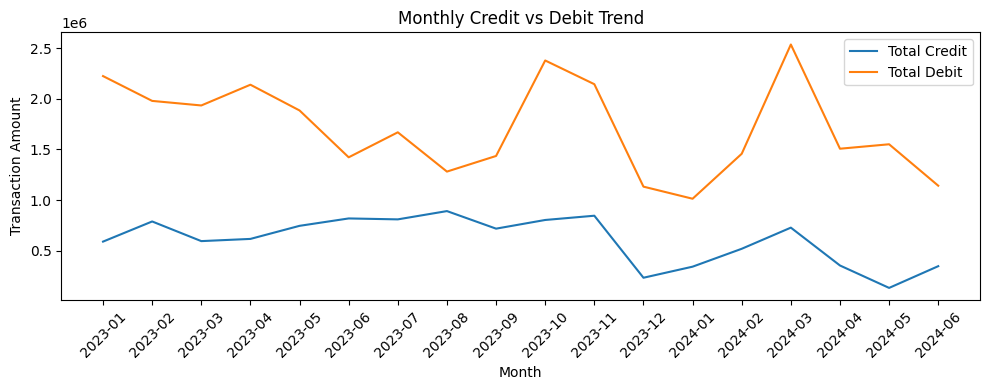

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(monthly_summary["Month"].astype(str),
         monthly_summary["TotalCredit"],
         label="Total Credit")

plt.plot(monthly_summary["Month"].astype(str),
         monthly_summary["TotalDebit"],
         label="Total Debit")

plt.xticks(rotation=45)
plt.title("Monthly Credit vs Debit Trend")
plt.xlabel("Month")
plt.ylabel("Transaction Amount")
plt.legend()
plt.tight_layout()
plt.show()

## Transaction Amount Distribution

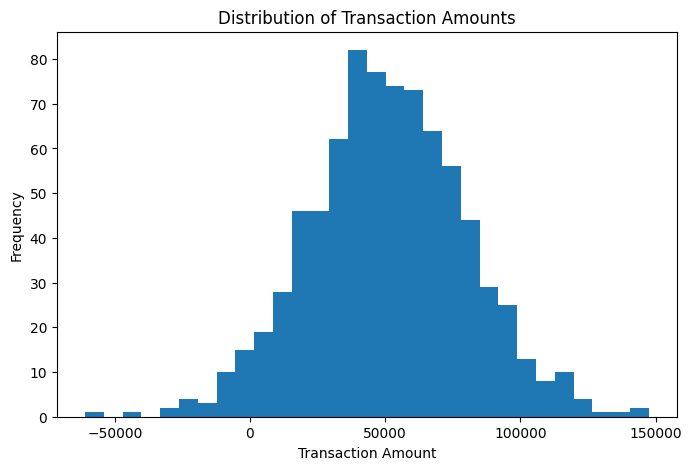

In [40]:
plt.figure(figsize=(8,5))
plt.hist(df["TransactionAmount"], bins=30)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

## Account Balance Distribution (Risk View)

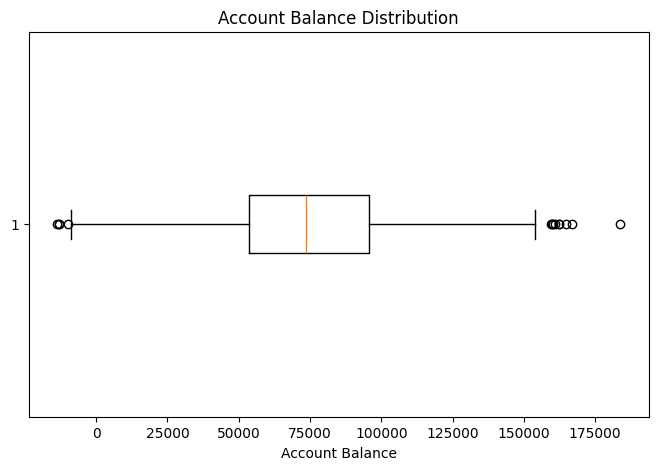

In [41]:
plt.figure(figsize=(8,5))
plt.boxplot(df["AccountBalance"], vert=False)
plt.title("Account Balance Distribution")
plt.xlabel("Account Balance")
plt.show()

## Activity Level Distribution

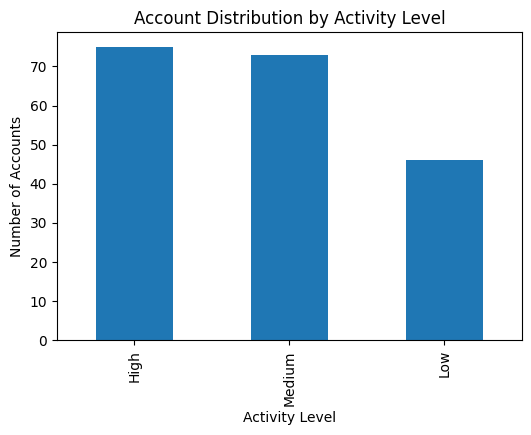

In [42]:
activity_counts = activity["ActivityLevel"].value_counts()

plt.figure(figsize=(6,4))
activity_counts.plot(kind="bar")
plt.title("Account Distribution by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Number of Accounts")
plt.show()

## Balance vs Transaction Volume (Customer Segmentation)

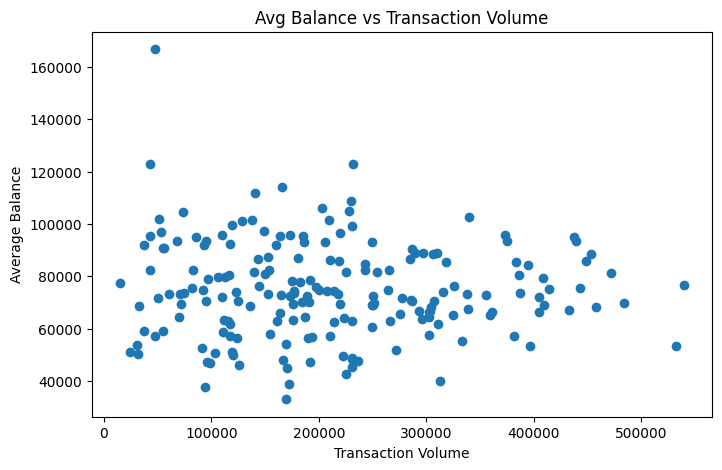

In [43]:
plt.figure(figsize=(8,5))
plt.scatter(account_profile["TransactionVolume"],
            account_profile["AvgBalance"])
plt.title("Avg Balance vs Transaction Volume")
plt.xlabel("Transaction Volume")
plt.ylabel("Average Balance")
plt.show()

## Net Transaction Trend Over Time

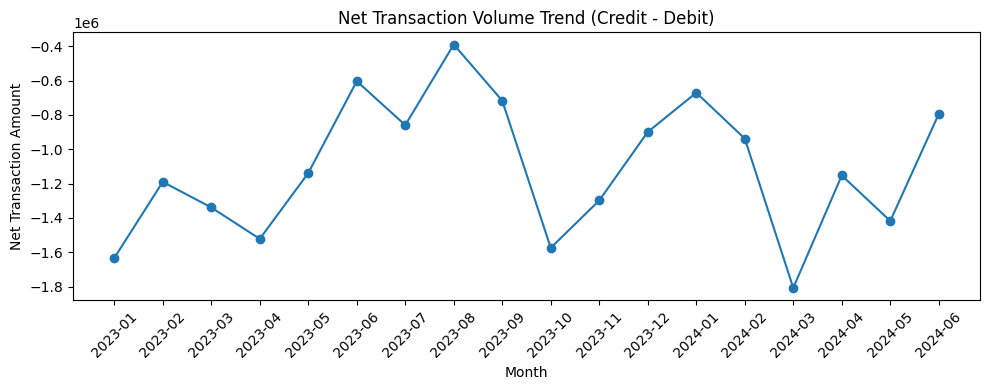

In [49]:
monthly_summary_plot = monthly_summary.copy()
monthly_summary_plot["Month"] = monthly_summary_plot["Month"].astype(str)

plt.figure(figsize=(10,4))
plt.plot(
    monthly_summary_plot["Month"],
    monthly_summary_plot["NetTransaction"],
    marker="o"
)
plt.xticks(rotation=45)
plt.title("Net Transaction Volume Trend (Credit - Debit)")
plt.xlabel("Month")
plt.ylabel("Net Transaction Amount")
plt.tight_layout()
plt.show()

## Balance Volatility Distribution (Risk Focus)

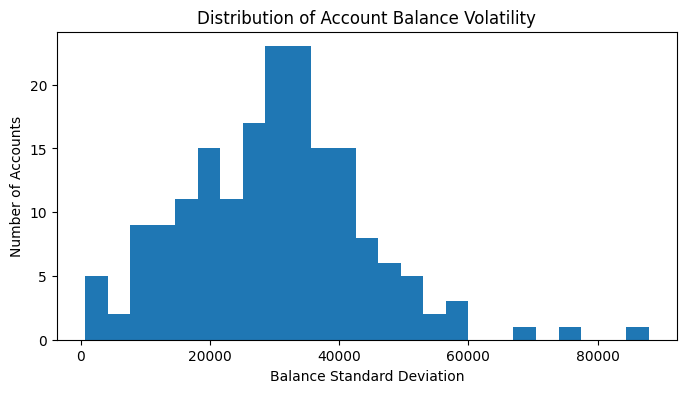

In [50]:
volatility_clean = balance_volatility["BalanceStdDev"].dropna()

plt.figure(figsize=(8,4))
plt.hist(volatility_clean, bins=25)
plt.title("Distribution of Account Balance Volatility")
plt.xlabel("Balance Standard Deviation")
plt.ylabel("Number of Accounts")
plt.show()

<hr>
<h1>Task 6: Hypothesis Testing</h1>

<p>
This task evaluates whether accounts with high transaction volume maintain statistically higher
average balances compared to low transaction volume accounts. Rather than relying on assumptions,
a formal hypothesis test was conducted to support data-driven decision-making.
</p>

<h4>Hypothesis Formulation</h4>
<ul>
  <li><b>Null Hypothesis (H<sub>0</sub>):</b> High-volume transaction accounts do not have higher average balances than low-volume accounts.</li>
  <li><b>Alternative Hypothesis (H<sub>1</sub>):</b> High-volume transaction accounts have higher average balances than low-volume accounts.</li>
</ul>

<h4>Methodology</h4>
<ul>
  <li>Accounts were segmented into high- and low-volume groups using the median transaction volume.</li>
  <li>Average account balance was used as a proxy for financial strength.</li>
  <li>A two-sample Welch’s t-test was applied at a 95% confidence level (α = 0.05).</li>
</ul>

<h4>Results & Interpretation</h4>
<ul>
  <li>The computed p-value was greater than 0.05.</li>
  <li>The null hypothesis was not rejected.</li>
  <li>This indicates no statistically significant difference in average balances between high- and low-volume accounts.</li>
</ul>

<h4>Business Insight</h4>
<p>
The results suggest that high transaction activity does not necessarily translate into higher
financial strength. This reinforces the need to evaluate customer value using balance stability
and net inflow metrics rather than transaction volume alone.
</p>

<p>
Overall, Task 6 demonstrates the importance of statistical validation in customer segmentation
and risk assessment, preventing decision-making based purely on behavioral assumptions.
</p>
<hr>

## Segment accounts by transaction volume

In [58]:
# Define threshold using median transaction volume
volume_threshold = account_profile["TransactionVolume"].median()

high_volume_accounts = account_profile[
    account_profile["TransactionVolume"] >= volume_threshold
]["AvgBalance"]

low_volume_accounts = account_profile[
    account_profile["TransactionVolume"] < volume_threshold
]["AvgBalance"]

high_volume_accounts.mean(), low_volume_accounts.mean()

(np.float64(74187.37663618312), np.float64(75334.73918822767))

## Perform hypothesis test (t‑test)

In [56]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    high_volume_accounts,
    low_volume_accounts,
    equal_var=False  # Welch’s t-test (safer)
)

t_stat, p_value

(np.float64(-0.4331698271374034), np.float64(0.6654077248563531))

## Decision rule

In [54]:
alpha = 0.05

if p_value < alpha:
    result = "Reject the null hypothesis"
else:
    result = "Fail to reject the null hypothesis"

result

'Fail to reject the null hypothesis'